In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy.signal import butter, filtfilt, resample
import pywt
import time
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns

1. Download Dataset

MIT-BIH Arrhythmia Database (https://doi.org/10.13026/C2F305)

In [2]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

2. Visualizing Dataset

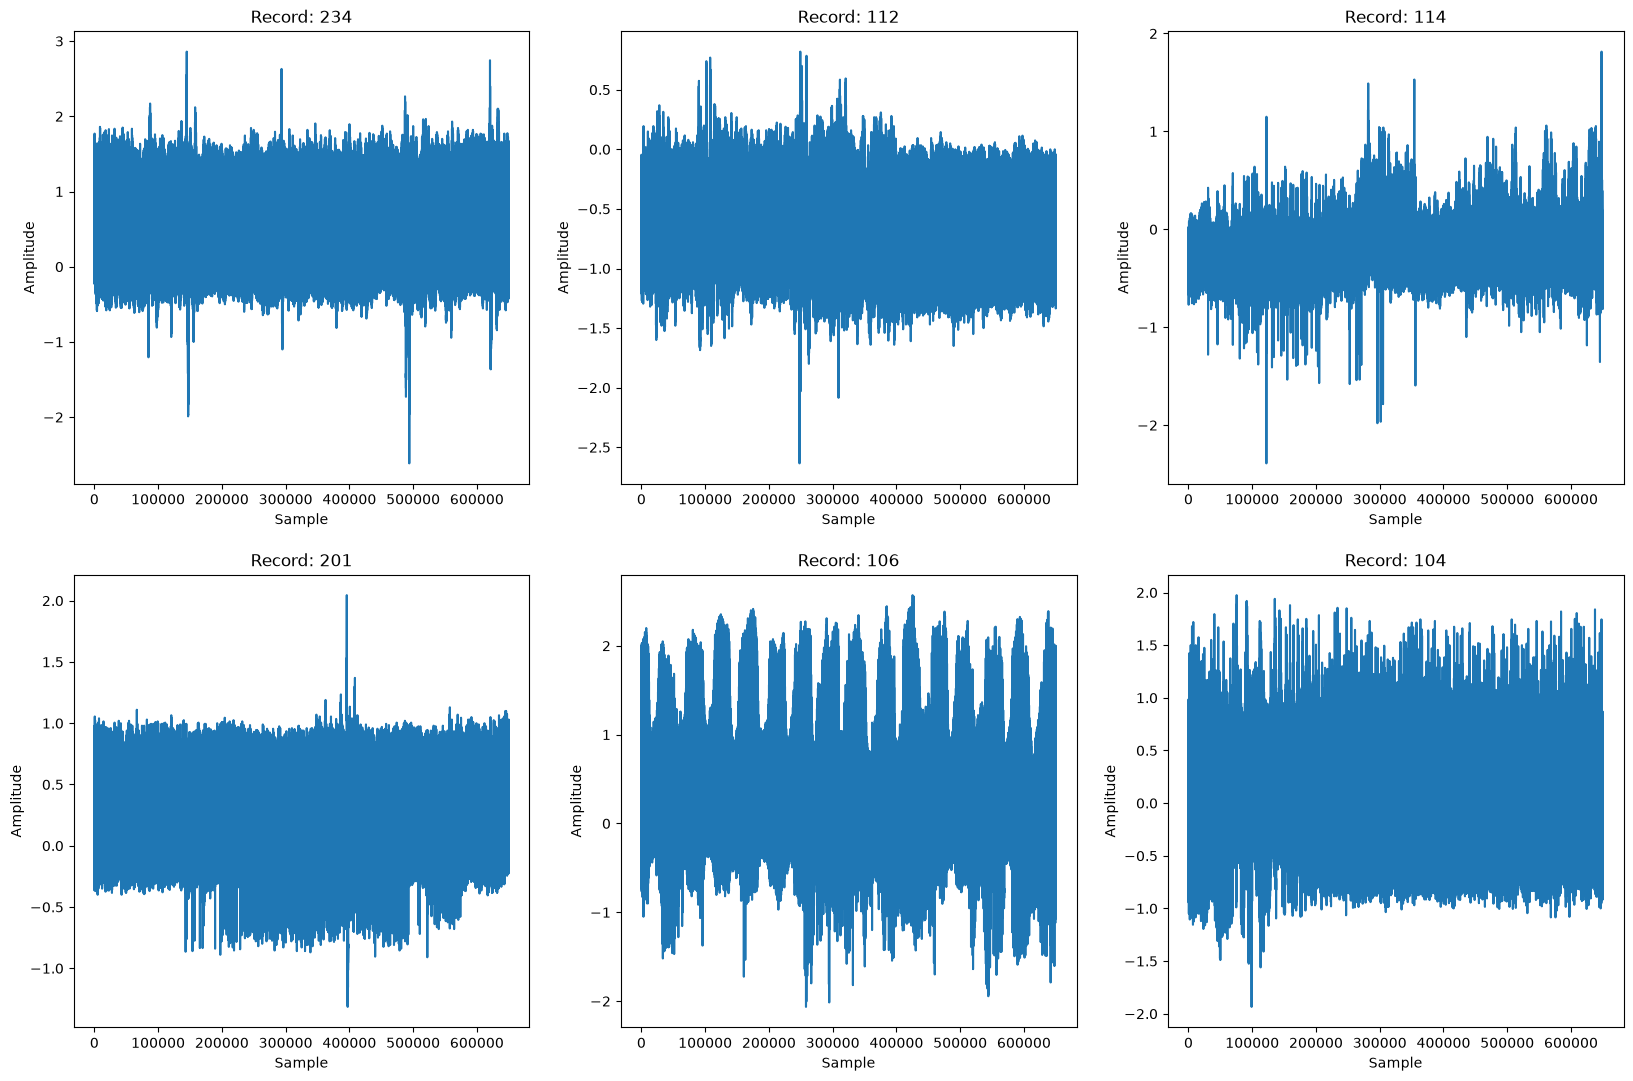

In [3]:
records = [
    f[:-4]
    for f in os.listdir("mitdb")
    if f.endswith(".hea")
]

plt.figure(figsize=(20, 20))

all_classes = os.listdir('mitdb')
random_records = random.sample(records, 6)

for counter, random_record in enumerate(random_records, 1):
    ecg_record = wfdb.rdrecord(f'mitdb/{random_record}')
    plt.subplot(3, 3, counter)
    plt.plot(ecg_record.p_signal[:, 0])
    plt.title(f"Record: {random_record}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

3. Data Loading

AAMI_MAPPING & CLASS_NAMES: Groups detailed doctor annotations into 5 standard AAMI classes (N, S, V, F, Q) to make labels uniform and ready for model training.

wfdb.rdrecord: Reads the raw continuous ECG signal in physical voltage (mV).

wfdb.rdann: Reads the expert-annotated R-peak timestamps and heartbeat labels.

MLII Detection: Automatically selects the Modified Limb Lead II channel, ensuring consistency across all patient records.

if symbol in AAMI_MAPPING: Keeps only valid heartbeats and removes non-beat markers (such as noise artifacts or rhythm changes).

In [4]:
AAMI_MAPPING = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
def load_mitdb_record(record_name, data_dir='mitdb'):
    record_path = os.path.join(data_dir, str(record_name))
    
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, 'atr')
    
    fs = record.fs
    lead_idx = record.sig_name.index('MLII') if 'MLII' in record.sig_name else 0
    signal = record.p_signal[:, lead_idx]
    
    r_peaks = []
    labels = []
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol in AAMI_MAPPING:
            r_peaks.append(sample)
            labels.append(AAMI_MAPPING[symbol])
            
    return signal, np.array(r_peaks, dtype=int), np.array(labels, dtype=int), fs

4. Filtering

filter_butterworth (Scenario 2):

- Uses a bandpass filter between 0.5 Hz and 45 Hz.
- Eliminates baseline drift (breathing movements below 0.5 Hz) and electrical powerline noise (above 45 Hz).
- Uses filtfilt (forward-backward filtering) to prevent phase distortion, ensuring the R-peak position does not shift.

filter_dwt_sym10 (Scenario 3):

- Breaks down the signal into 8 frequency levels using the Symlet-10 (sym10) wavelet, whose mathematical shape closely matches the ECG QRS complex.
- coeffs[0] = 0: Removes the lowest frequency component (baseline wander).
- coeffs[1] & coeffs[2] = 0: Removes high-frequency noise and powerline interference.
- Reconstructs a clean ECG signal while preserving the sharp peaks of heartbeats.

In [5]:
def filter_butterworth(signal, fs=360, lowcut=0.5, highcut=45.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = min(highcut, nyquist - 0.5) / nyquist
    b, a = butter(order, [low, high], btype='bandpass')
    return filtfilt(b, a, signal)

def filter_dwt_sym10(signal, wavelet='sym10', level=8):
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    coeffs[0] = np.zeros_like(coeffs[0])
    coeffs[1] = np.zeros_like(coeffs[1])
    coeffs[2] = np.zeros_like(coeffs[2])
    return pywt.waverec(coeffs, wavelet=wavelet)[:len(signal)]

5. Normalization 

normalize_minmax (Scenario 4):

- Scales all voltage values strictly into the bounded range of [−1,1].
- Prevents large amplitude spikes from dominating gradient updates during neural network backpropagation.

normalize_zscore (Scenario 5):

- Transforms the signal distribution to have a mean of μ=0 and standard deviation of σ=1.
- Centers the baseline at zero and standardizes variability across different patients and electrode placements.

eps=1e-8:

- A tiny constant (epsilon) added to the denominator to prevent a ZeroDivisionError if the signal happens to be completely flat.

In [6]:
def normalize_minmax(signal, feature_range=(-1, 1), eps=1e-8):
    min_val = np.min(signal)
    max_val = np.max(signal)
    a, b = feature_range
    normalized = (signal - min_val) / (max_val - min_val + eps)
    return a + normalized * (b - a)

def normalize_zscore(signal, eps=1e-8):
    mean = np.mean(signal)
    std = np.std(signal)
    return (signal - mean) / (std + eps)

6. Resample

resample_record (Used in Scenarios 6 & 7):

- Downsampling: Reduces sampling rate from the original 360 Hz down to 100 Hz or 50 Hz using scipy.signal.resample.

- Time Scaling: Recalculates the exact position of each R-peak by multiplying with target_fs / original_fs, keeping the annotations - perfectly aligned with the newly scaled signal.

extract_beats (Heartbeat Segmentation):

- Beat Windowing: Cuts each continuous signal into individual heartbeats centered around the detected R-peaks.
- Window Proportions:
    - 0.3 seconds before R-peak: Captures atrial depolarization (P-wave and PR segment).
    - 0.5 seconds after R-peak: Captures ventricular repolarization (ST segment and T-wave).
- Boundary Guard: Safely skips beats that are too close to the beginning or end of the recording to prevent out-of-bounds indexing.
- Output Shape: Produces a 2D array (num_beats, window_length) ready to be reshaped into (num_beats, window_length, 1) for 1D CNN-LSTM input.

In [7]:
def resample_record(signal, r_peaks, original_fs=360, target_fs=100):
    if target_fs == original_fs:
        return signal, r_peaks, original_fs
        
    num_samples = int(len(signal) * (target_fs / original_fs))
    resampled_signal = resample(signal, num_samples)
    
    scale_factor = target_fs / original_fs
    resampled_r_peaks = np.round(r_peaks * scale_factor).astype(int)
    
    return resampled_signal, resampled_r_peaks, target_fs
def extract_beats(signal, r_peaks, labels, fs, before_sec=0.3, after_sec=0.5):
    half_before = int(before_sec * fs)
    half_after = int(after_sec * fs)
    total_len = half_before + half_after
    
    beats = []
    valid_labels = []
    
    for r_peak, label in zip(r_peaks, labels):
        start = r_peak - half_before
        end = r_peak + half_after
        
        if start >= 0 and end <= len(signal):
            segment = signal[start:end]
            if len(segment) == total_len:
                beats.append(segment)
                valid_labels.append(label)
                
    return np.array(beats, dtype=np.float32), np.array(valid_labels, dtype=int)

build_cnn_lstm_model (Hybrid Architecture):

- Dynamic Input (input_shape): Accepts any heartbeat length (timesteps, 1) dynamically. This allows the exact same model definition to be reused across 360 Hz, 100 Hz, and 50 Hz.
- 1D-CNN Layers: Extracts spatial wave morphology (detecting P-waves, sharp QRS spikes, and T-waves).
- Bidirectional LSTM: Analyzes the sequential relationship and temporal rhythm of the heartbeat forward and backward.
- Batch Normalization & Dropout: Stabilizes gradient flow and guards against overfitting.

compute_cost_sensitive_weights (Handling Severe Class Imbalance):

- In the MIT-BIH dataset, normal beats (N) make up ~85–90% of all data, while arrhythmias (S, V, F, Q) are rare.
- Computes inverse-frequency weights so misclassifying rare life-threatening arrhythmias incurs a much heavier mathematical loss penalty during backpropagation.

evaluate_model_performance (Standard Medical Evaluation):

- Computes all target dependent variables: Accuracy, Macro-Precision, Macro-Recall (Sensitivity), Macro-F1, and Macro-Specificity.
- Inference Latency (latency_ms): Measures the exact inference speed in milliseconds per single heartbeat, testing whether downsampling (100 Hz / 50 Hz) delivers tangible real-time latency gains.

In [8]:
DS1_TRAIN_RECORDS = [
    '101', '106', '108', '109', '112', '114', '115', '116', '118', '119',
    '122', '124', '201', '203', '205', '207', '208', '209', '215', '220',
    '223', '230'
]
DS2_TEST_RECORDS = [
    '100', '103', '105', '111', '113', '117', '121', '123', '200', '202',
    '210', '212', '213', '214', '219', '221', '222', '228', '231', '232',
    '233', '234'
]
def prepare_dataset_for_scenario(records, filter_type=None, norm_type=None, target_fs=360, data_dir='mitdb'):
    all_beats = []
    all_labels = []
    
    for rec in records:
        signal, r_peaks, labels, fs = load_mitdb_record(rec, data_dir=data_dir)
        
        if len(r_peaks) == 0:
            continue
            
        if filter_type == 'butterworth':
            signal = filter_butterworth(signal, fs=fs)
        elif filter_type == 'dwt':
            signal = filter_dwt_sym10(signal)
            
        if target_fs != fs:
            signal, r_peaks, fs = resample_record(signal, r_peaks, original_fs=fs, target_fs=target_fs)
            
        beats, beat_labels = extract_beats(signal, r_peaks, labels, fs=fs)
        
        if norm_type == 'minmax':
            beats = np.array([normalize_minmax(b) for b in beats], dtype=np.float32)
        elif norm_type == 'zscore':
            beats = np.array([normalize_zscore(b) for b in beats], dtype=np.float32)
            
        if len(beats) > 0:
            all_beats.append(beats)
            all_labels.append(beat_labels)
            
    X = np.concatenate(all_beats, axis=0)
    y = np.concatenate(all_labels, axis=0)
    
    X = np.expand_dims(X, axis=-1)
    return X, y

def build_cnn_lstm_model(input_shape, num_classes=5):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv1D(filters=32, kernel_size=5, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(filters=64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def compute_cost_sensitive_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    return dict(zip(classes, weights))

def evaluate_model_performance(model, X_test, y_test):
    start_time = time.perf_counter()
    y_pred_probs = model.predict(X_test, batch_size=128, verbose=0)
    end_time = time.perf_counter()
    
    total_time_ms = (end_time - start_time) * 1000.0
    latency_per_sample_ms = total_time_ms / len(X_test)
    
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred)
    specificities = []
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec)
    macro_spec = np.mean(specificities)
    
    return {
        'accuracy': acc * 100.0,
        'precision': prec * 100.0,
        'recall': rec * 100.0,
        'f1_score': f1 * 100.0,
        'specificity': macro_spec * 100.0,
        'latency_ms': latency_per_sample_ms,
        'confusion_matrix': cm
    }


tf.keras.backend.clear_session():

- Clears memory and resets internal TensorFlow graph states at the start of each scenario run, ensuring zero weight leakage or memory accumulation across experiments.

Dynamic Data Extraction:

- Calls prepare_dataset_for_scenario with the specified configuration (filtering, normalization, and sampling rate) for both DS1_TRAIN_RECORDS and DS2_TEST_RECORDS.

Training Optimization:

- EarlyStopping: Halts training if validation loss stops improving for 4 consecutive epochs and restores the best model weights.
- ReduceLROnPlateau: Automatically cuts the learning rate by half when validation loss plateaus, allowing finer convergence.
- class_weight=class_weights: Enforces cost-sensitive penalization during gradient updates.

Standardized Metric Summary:

- Gathers all measured dependent variables (Accuracy, Precision, Recall, F1-Score, Specificity, and Latency) into a uniform dictionary, ready to be displayed as a comparative benchmark table.

In [9]:
def run_experiment_scenario(scenario_name, filter_type=None, norm_type=None, target_fs=360, epochs=20, batch_size=128):
    tf.keras.backend.clear_session()
    
    print(f"=== Running {scenario_name} (Filter: {filter_type}, Norm: {norm_type}, Fs: {target_fs}Hz) ===")
    
    X_train, y_train = prepare_dataset_for_scenario(
        records=DS1_TRAIN_RECORDS,
        filter_type=filter_type,
        norm_type=norm_type,
        target_fs=target_fs
    )
    
    X_test, y_test = prepare_dataset_for_scenario(
        records=DS2_TEST_RECORDS,
        filter_type=filter_type,
        norm_type=norm_type,
        target_fs=target_fs
    )
    
    print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]} | Input shape: {X_train.shape[1:]}")
    
    class_weights = compute_cost_sensitive_weights(y_train)
    
    model = build_cnn_lstm_model(input_shape=X_train.shape[1:], num_classes=5)
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
    ]
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    
    results = evaluate_model_performance(model, X_test, y_test)
    
    summary = {
        'Scenario': scenario_name,
        'Filter': str(filter_type),
        'Normalization': str(norm_type),
        'Fs (Hz)': target_fs,
        'Accuracy (%)': round(results['accuracy'], 2),
        'Precision (%)': round(results['precision'], 2),
        'Recall (%)': round(results['recall'], 2),
        'F1-Score (%)': round(results['f1_score'], 2),
        'Specificity (%)': round(results['specificity'], 2),
        'Latency (ms)': round(results['latency_ms'], 4)
    }
    
    return summary, model, results['confusion_matrix']

In [10]:
all_results = []
confusion_matrices = {}
# Skenario 1: Baseline Raw Signal
res_s1, model_s1, cm_s1 = run_experiment_scenario(
    scenario_name='Scenario 1: Raw Baseline',
    filter_type=None,
    norm_type=None,
    target_fs=360
)
all_results.append(res_s1)
confusion_matrices['Scenario 1'] = cm_s1
# Skenario 2: Butterworth Bandpass (0.5 - 45 Hz)
res_s2, model_s2, cm_s2 = run_experiment_scenario(
    scenario_name='Scenario 2: Butterworth Bandpass',
    filter_type='butterworth',
    norm_type=None,
    target_fs=360
)
all_results.append(res_s2)
confusion_matrices['Scenario 2'] = cm_s2
# Skenario 3: DWT Symlet-10
res_s3, model_s3, cm_s3 = run_experiment_scenario(
    scenario_name='Scenario 3: DWT Symlet-10',
    filter_type='dwt',
    norm_type=None,
    target_fs=360
)
all_results.append(res_s3)
confusion_matrices['Scenario 3'] = cm_s3
# Penentuan Filter Terbaik Berdasarkan Macro F1-Score
best_filter = 'butterworth' if res_s2['F1-Score (%)'] >= res_s3['F1-Score (%)'] else 'dwt'
print(f"\n>>> Best Filtering Method: {best_filter.upper()} (Selected for Scenarios 4 to 7) <<<")
df_phase1 = pd.DataFrame(all_results)
display(df_phase1)


=== Running Scenario 1: Raw Baseline (Filter: None, Norm: None, Fs: 360Hz) ===
Train samples: 51000 | Test samples: 49691 | Input shape: (288, 1)
Epoch 1/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.4896 - loss: 1.7190 - val_accuracy: 0.8923 - val_loss: 0.9480 - learning_rate: 0.0010
Epoch 2/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 73s 214ms/step - accuracy: 0.5282 - loss: 1.7719 - val_accuracy: 0.5752 - val_loss: 1.2831 - learning_rate: 0.0010
Epoch 3/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 56s 135ms/step - accuracy: 0.5656 - loss: 1.4319 - val_accuracy: 0.8655 - val_loss: 1.1186 - learning_rate: 0.0010
Epoch 4/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.6601 - loss: 1.0648 - val_accuracy: 0.6852 - val_loss: 1.0489 - learning_rate: 5.0000e-04
Epoch 5/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.6899 - loss: 0.9706 - val_accuracy: 0.7610 - val_loss: 1.1803 - learning_rate: 5.0000e-04
=== Running Scenario 2: Butterworth Bandpass (Filter: butterworth, Norm:

,Scenario,Filter,Normalization,Fs (Hz),Accuracy (%),Precision (%),Recall (%),F1-Score (%),Specificity (%),Latency (ms)
0,Scenario 1: Raw Baseline,None,None,360,80.11,29.23,20.32,21.30,82.62,0.2019
1,Scenario 2: Butterworth Bandpass,butterworth,None,360,77.29,27.57,34.63,28.77,88.47,0.2057
2,Scenario 3: DWT Symlet-10,dwt,None,360,67.67,26.84,29.66,26.36,88.93,0.2053


In [11]:
# Skenario 4: Butterworth + Min-Max Scaling ([-1, 1])
res_s4, model_s4, cm_s4 = run_experiment_scenario(
    scenario_name='Scenario 4: Butterworth + Min-Max',
    filter_type='butterworth',
    norm_type='minmax',
    target_fs=360
)
all_results.append(res_s4)
confusion_matrices['Scenario 4'] = cm_s4

# Skenario 5: Butterworth + Z-score Standardization
res_s5, model_s5, cm_s5 = run_experiment_scenario(
    scenario_name='Scenario 5: Butterworth + Z-Score',
    filter_type='butterworth',
    norm_type='zscore',
    target_fs=360
)
all_results.append(res_s5)
confusion_matrices['Scenario 5'] = cm_s5

# Penentuan Normalisasi Terbaik Berdasarkan Macro F1-Score
best_norm = 'minmax' if res_s4['F1-Score (%)'] >= res_s5['F1-Score (%)'] else 'zscore'
print(f"\n>>> Best Normalization Method: {best_norm.upper()} <<<")

df_phase2 = pd.DataFrame(all_results)
display(df_phase2)

=== Running Scenario 4: Butterworth + Min-Max (Filter: butterworth, Norm: minmax, Fs: 360Hz) ===
Train samples: 51000 | Test samples: 49691 | Input shape: (288, 1)
Epoch 1/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.4804 - loss: 1.4442 - val_accuracy: 0.4863 - val_loss: 1.1195 - learning_rate: 0.0010
Epoch 2/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 28s 84ms/step - accuracy: 0.5992 - loss: 1.2359 - val_accuracy: 0.7592 - val_loss: 0.7048 - learning_rate: 0.0010
Epoch 3/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - accuracy: 0.6179 - loss: 1.0469 - val_accuracy: 0.6417 - val_loss: 0.8411 - learning_rate: 0.0010
Epoch 4/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.6518 - loss: 0.9228 - val_accuracy: 0.7069 - val_loss: 0.7934 - learning_rate: 0.0010
Epoch 5/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.6900 - loss: 0.8226 - val_accuracy: 0.8196 - val_loss: 0.5996 - learning_rate: 5.0000e-04
Epoch 6/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accura

,Scenario,Filter,Normalization,Fs (Hz),Accuracy (%),Precision (%),Recall (%),F1-Score (%),Specificity (%),Latency (ms)
0,Scenario 1: Raw Baseline,None,None,360,80.11,29.23,20.32,21.30,82.62,0.2019
1,Scenario 2: Butterworth Bandpass,butterworth,None,360,77.29,27.57,34.63,28.77,88.47,0.2057
2,Scenario 3: DWT Symlet-10,dwt,None,360,67.67,26.84,29.66,26.36,88.93,0.2053
3,Scenario 4: Butterworth + Min-Max,butterworth,minmax,360,60.64,28.53,32.34,27.42,85.34,0.1953
4,Scenario 5: Butterworth + Z-Score,butterworth,zscore,360,72.94,25.03,23.24,23.71,81.94,0.1996


In [12]:
# Skenario 6: Butterworth + Min-Max + Downsampling ke 100 Hz
res_s6, model_s6, cm_s6 = run_experiment_scenario(
    scenario_name='Scenario 6: 100 Hz Downsampling',
    filter_type=best_filter,
    norm_type=best_norm,
    target_fs=100
)
all_results.append(res_s6)
confusion_matrices['Scenario 6'] = cm_s6
# Skenario 7: Butterworth + Min-Max + Downsampling ke 50 Hz
res_s7, model_s7, cm_s7 = run_experiment_scenario(
    scenario_name='Scenario 7: 50 Hz Downsampling',
    filter_type=best_filter,
    norm_type=best_norm,
    target_fs=50
)
all_results.append(res_s7)
confusion_matrices['Scenario 7'] = cm_s7
# Tabel Rekapitulasi Akhir Seluruh 7 Skenario
df_final = pd.DataFrame(all_results)
display(df_final)

=== Running Scenario 6: 100 Hz Downsampling (Filter: butterworth, Norm: minmax, Fs: 100Hz) ===
Train samples: 51000 | Test samples: 49691 | Input shape: (80, 1)
Epoch 1/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4792 - loss: 1.5267 - val_accuracy: 0.6420 - val_loss: 0.9245 - learning_rate: 0.0010
Epoch 2/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5408 - loss: 1.2701 - val_accuracy: 0.7724 - val_loss: 0.8684 - learning_rate: 0.0010
Epoch 3/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5916 - loss: 1.0149 - val_accuracy: 0.8427 - val_loss: 0.7544 - learning_rate: 0.0010
Epoch 4/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5816 - loss: 0.9997 - val_accuracy: 0.5237 - val_loss: 0.8629 - learning_rate: 0.0010
Epoch 5/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6317 - loss: 0.9763 - val_accuracy: 0.7855 - val_loss: 0.8091 - learning_rate: 0.0010
Epoch 6/20
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6795 -

,Scenario,Filter,Normalization,Fs (Hz),Accuracy (%),Precision (%),Recall (%),F1-Score (%),Specificity (%),Latency (ms)
0,Scenario 1: Raw Baseline,None,None,360,80.11,29.23,20.32,21.30,82.62,0.2019
1,Scenario 2: Butterworth Bandpass,butterworth,None,360,77.29,27.57,34.63,28.77,88.47,0.2057
2,Scenario 3: DWT Symlet-10,dwt,None,360,67.67,26.84,29.66,26.36,88.93,0.2053
3,Scenario 4: Butterworth + Min-Max,butterworth,minmax,360,60.64,28.53,32.34,27.42,85.34,0.1953
4,Scenario 5: Butterworth + Z-Score,butterworth,zscore,360,72.94,25.03,23.24,23.71,81.94,0.1996
5,Scenario 6: 100 Hz Downsampling,butterworth,minmax,100,54.12,24.01,22.60,20.49,83.81,0.0800
6,Scenario 7: 50 Hz Downsampling,butterworth,minmax,50,67.80,29.86,31.93,27.36,86.30,0.0617


=== TABEL HASIL KOMPARASI FINAL (7 SKENARIO) ===


,Scenario,Filter,Normalization,Fs (Hz),Accuracy (%),Precision (%),Recall (%),F1-Score (%),Specificity (%),Latency (ms)
0,Scenario 1: Raw Baseline,None,None,360,80.11,29.23,20.32,21.30,82.62,0.2019
1,Scenario 2: Butterworth Bandpass,butterworth,None,360,77.29,27.57,34.63,28.77,88.47,0.2057
2,Scenario 3: DWT Symlet-10,dwt,None,360,67.67,26.84,29.66,26.36,88.93,0.2053
3,Scenario 4: Butterworth + Min-Max,butterworth,minmax,360,60.64,28.53,32.34,27.42,85.34,0.1953
4,Scenario 5: Butterworth + Z-Score,butterworth,zscore,360,72.94,25.03,23.24,23.71,81.94,0.1996
5,Scenario 6: 100 Hz Downsampling,butterworth,minmax,100,54.12,24.01,22.60,20.49,83.81,0.0800
6,Scenario 7: 50 Hz Downsampling,butterworth,minmax,50,67.80,29.86,31.93,27.36,86.30,0.0617


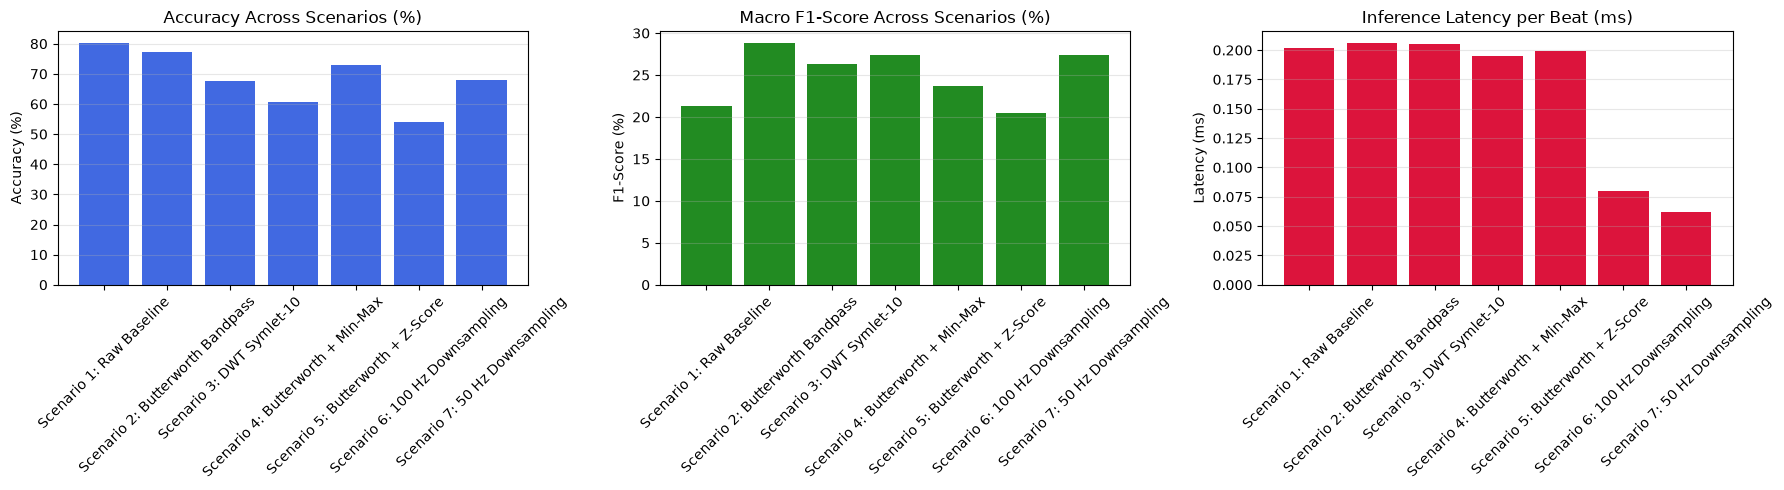

In [13]:
df_clean = pd.DataFrame(all_results[:7])

print("=== TABEL HASIL KOMPARASI FINAL (7 SKENARIO) ===")
display(df_clean)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(df_clean['Scenario'], df_clean['Accuracy (%)'], color='royalblue')
axes[0].set_title('Accuracy Across Scenarios (%)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(df_clean['Scenario'], df_clean['F1-Score (%)'], color='forestgreen')
axes[1].set_title('Macro F1-Score Across Scenarios (%)')
axes[1].set_ylabel('F1-Score (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(df_clean['Scenario'], df_clean['Latency (ms)'], color='crimson')
axes[2].set_title('Inference Latency per Beat (ms)')
axes[2].set_ylabel('Latency (ms)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

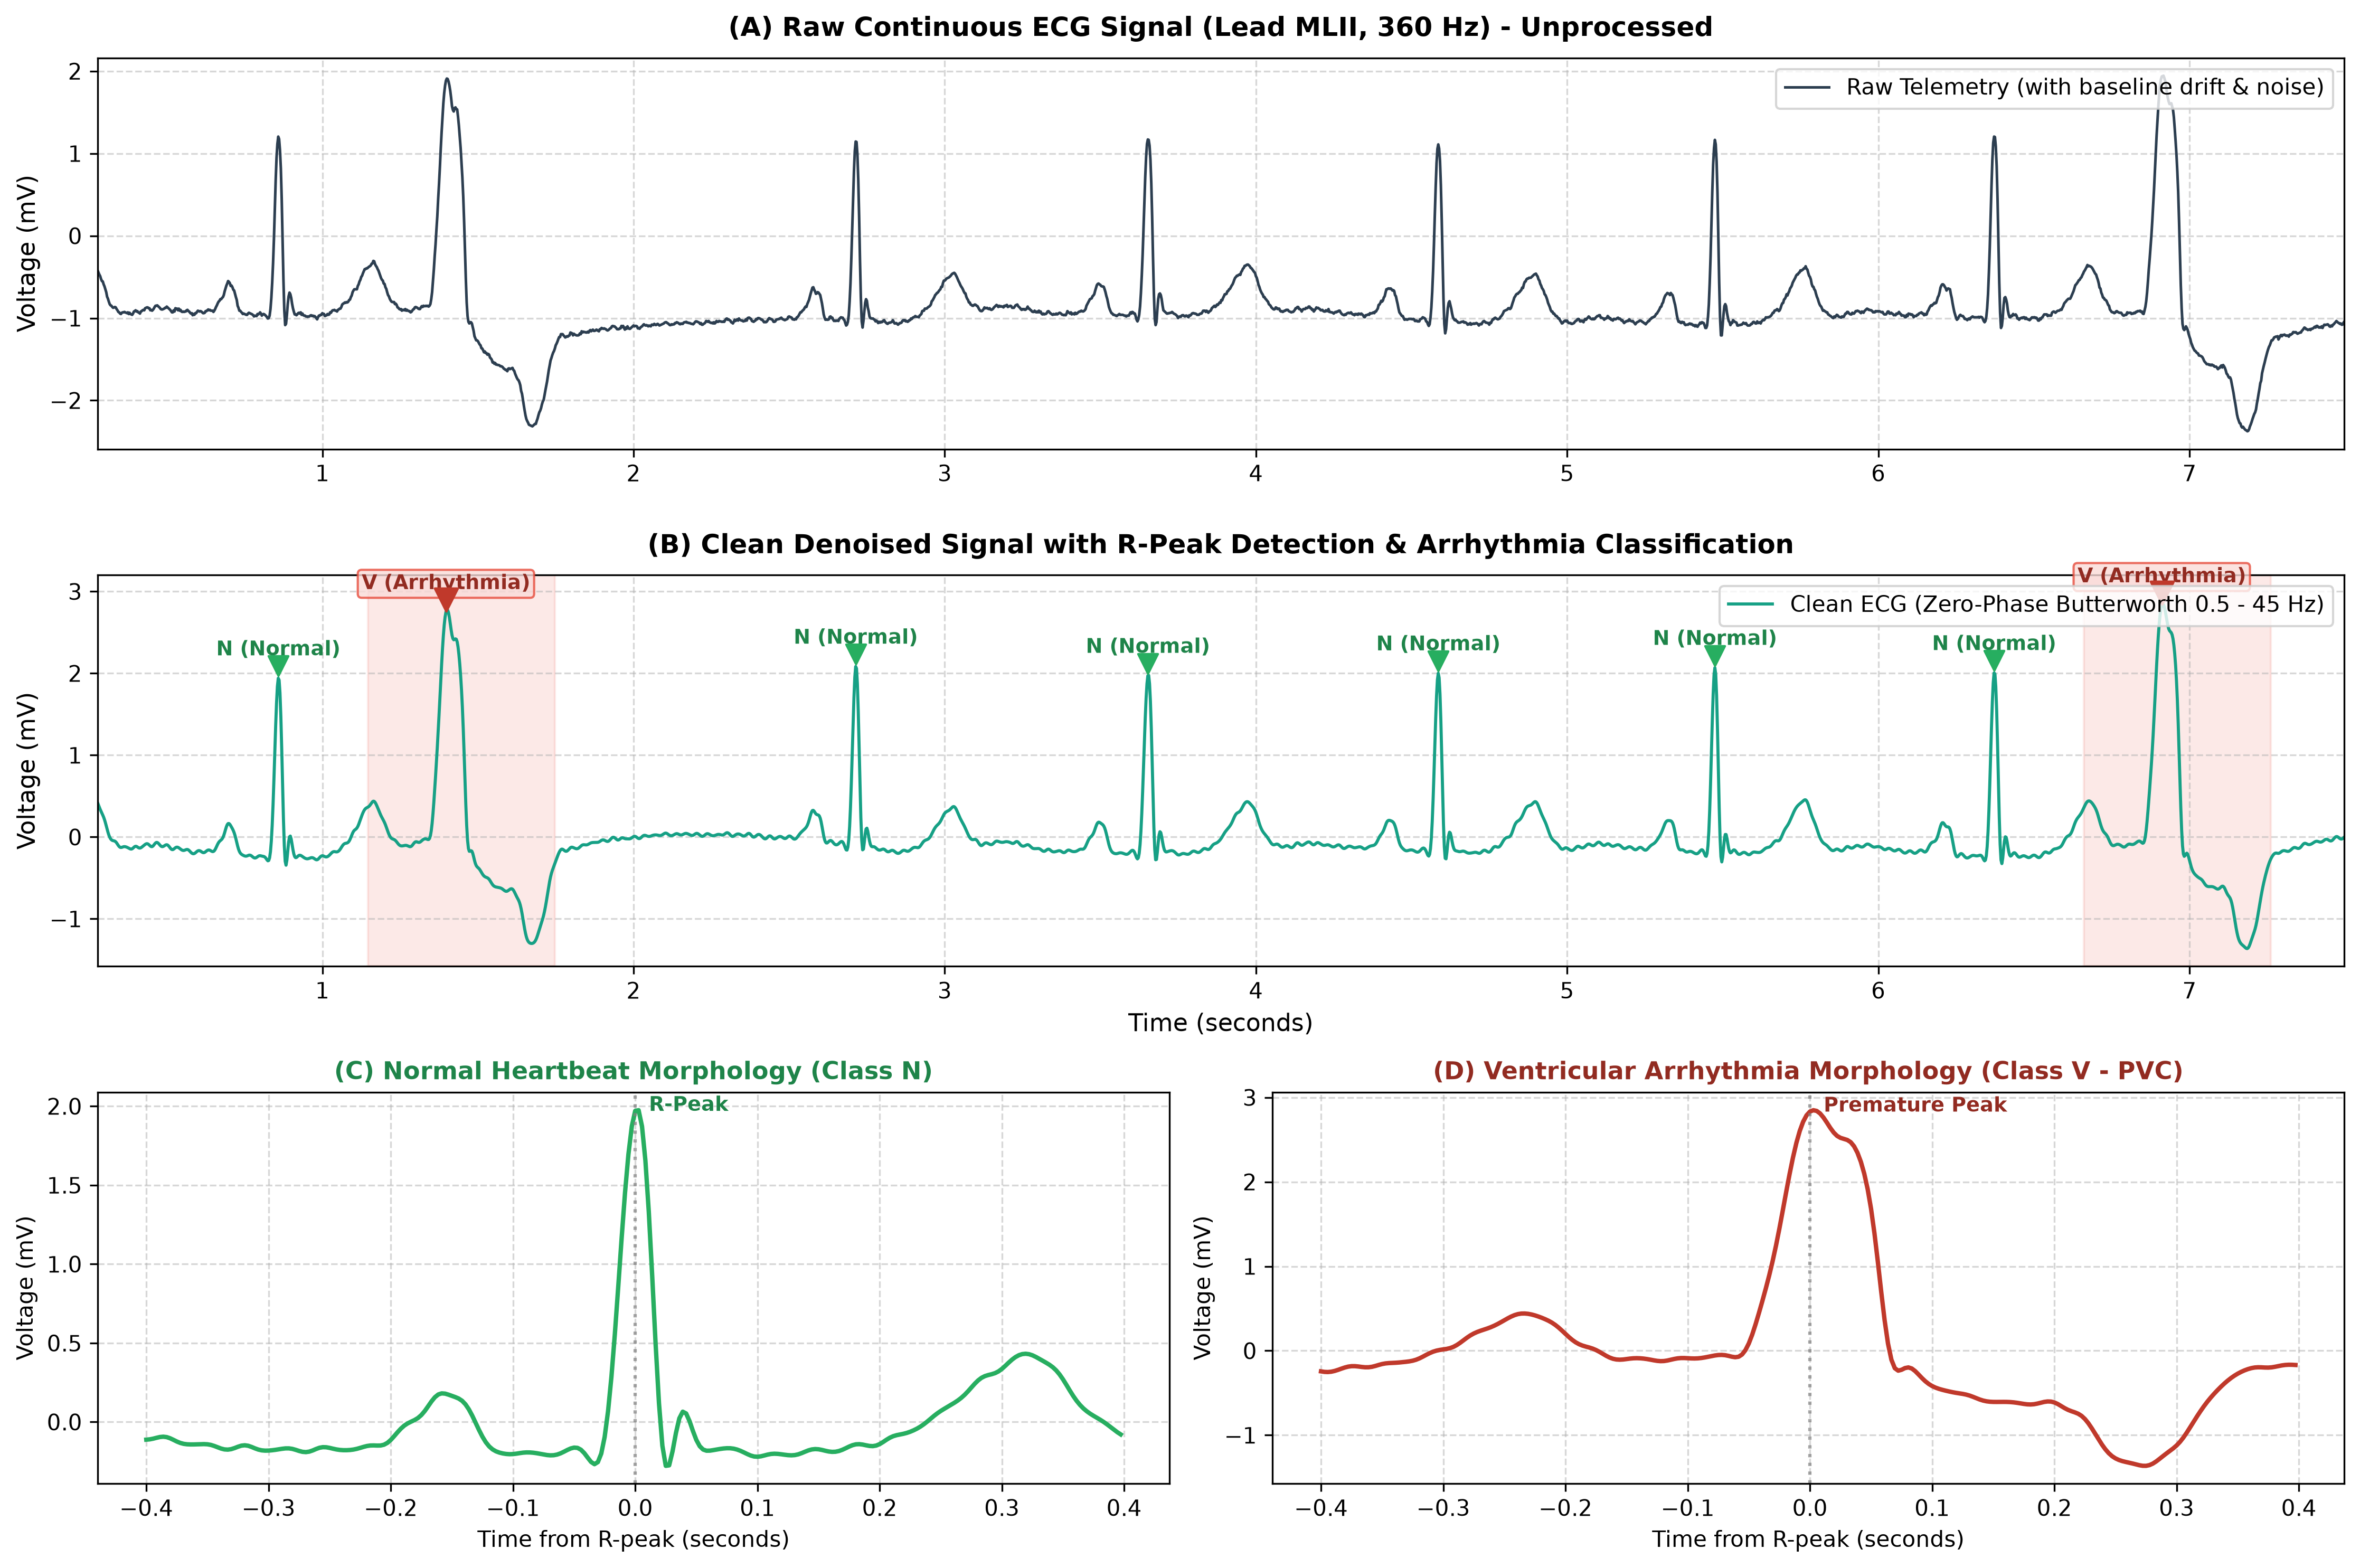

In [14]:
record_name = '119'
rec = wfdb.rdrecord(f'mitdb/{record_name}')
ann = wfdb.rdann(f'mitdb/{record_name}', 'atr')
sig = rec.p_signal[:, 0]
fs = rec.fs
nyq = 0.5 * fs
b, a = butter(3, [0.5 / nyq, 45.0 / nyq], btype='bandpass')
clean_sig = filtfilt(b, a, sig)
start_idx = 100
end_idx = 2700
t = np.arange(start_idx, end_idx) / fs
mask = (ann.sample >= start_idx) & (ann.sample < end_idx)
sub_samples = ann.sample[mask]
sub_symbols = [ann.symbol[i] for i in range(len(ann.sample)) if mask[i]]
fig = plt.figure(figsize=(15, 10), dpi=300)
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax1.plot(t, sig[start_idx:end_idx], color='#2c3e50', linewidth=1.2, label='Raw Telemetry (with baseline drift & noise)')
ax1.set_title('(A) Raw Continuous ECG Signal (Lead MLII, 360 Hz) - Unprocessed', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Voltage (mV)', fontsize=11)
ax1.set_xlim(t[0], t[-1])
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)
ax2 = plt.subplot2grid((3, 2), (1, 0), colspan=2)
ax2.plot(t, clean_sig[start_idx:end_idx], color='#16a085', linewidth=1.4, label='Clean ECG (Zero-Phase Butterworth 0.5 - 45 Hz)')
ax2.set_title('(B) Clean Denoised Signal with R-Peak Detection & Arrhythmia Classification', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.set_ylabel('Voltage (mV)', fontsize=11)
ax2.set_xlim(t[0], t[-1])
for s_idx, sym in zip(sub_samples, sub_symbols):
    t_peak = s_idx / fs
    v_peak = clean_sig[s_idx]
    if sym == 'N':
        ax2.scatter(t_peak, v_peak + 0.15, marker='v', color='#27ae60', s=80, zorder=5)
        ax2.text(t_peak, v_peak + 0.28, 'N (Normal)', color='#1e8449', fontsize=9, fontweight='bold', ha='center')
    elif sym == 'V':
        ax2.scatter(t_peak, v_peak + 0.15, marker='v', color='#c0392b', s=110, zorder=5)
        ax2.text(t_peak, v_peak + 0.28, 'V (Arrhythmia)', color='#922b21', fontsize=9, fontweight='bold', ha='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='#fadbd8', edgecolor='#e74c3c', alpha=0.8))
        ax2.axvspan(t_peak - 0.25, t_peak + 0.35, color='#e74c3c', alpha=0.12)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)
n_peak = 1315
v_peak = 2488
win = int(0.4 * fs)
ax3 = plt.subplot2grid((3, 2), (2, 0))
t_n = (np.arange(n_peak - win, n_peak + win) - n_peak) / fs
ax3.plot(t_n, clean_sig[n_peak - win : n_peak + win], color='#27ae60', linewidth=2.0)
ax3.set_title('(C) Normal Heartbeat Morphology (Class N)', fontsize=11, fontweight='bold', color='#1e8449')
ax3.set_xlabel('Time from R-peak (seconds)', fontsize=10)
ax3.set_ylabel('Voltage (mV)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.axvline(0, color='gray', linestyle=':', alpha=0.7)
ax3.text(0, clean_sig[n_peak], '  R-Peak', color='#1e8449', fontweight='bold', fontsize=9)
ax4 = plt.subplot2grid((3, 2), (2, 1))
t_v = (np.arange(v_peak - win, v_peak + win) - v_peak) / fs
ax4.plot(t_v, clean_sig[v_peak - win : v_peak + win], color='#c0392b', linewidth=2.0)
ax4.set_title('(D) Ventricular Arrhythmia Morphology (Class V - PVC)', fontsize=11, fontweight='bold', color='#922b21')
ax4.set_xlabel('Time from R-peak (seconds)', fontsize=10)
ax4.set_ylabel('Voltage (mV)', fontsize=10)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.axvline(0, color='gray', linestyle=':', alpha=0.7)
ax4.text(0, clean_sig[v_peak], '  Premature Peak', color='#922b21', fontweight='bold', fontsize=9)
plt.tight_layout()
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/ecg_raw_vs_filtered_portfolio.png', dpi=300, bbox_inches='tight')
plt.show()